In [1]:
import torch

In [2]:
torch.cuda.is_available()

True

In [3]:
torch.cuda.current_device()

0

In [4]:
torch.cuda.get_device_name(0)

'GRID A100D-40C'

In [90]:
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import matplotlib.pyplot as plt

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [17]:
df = pd.read_csv("NYCTaxiFares.csv")

In [18]:
df.head()

,pickup_datetime,fare_amount,fare_class,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2010-04-19 08:17:56 UTC,6.5,0,-73.992365,40.730521,-73.975499,40.744746,1
1,2010-04-17 15:43:53 UTC,6.9,0,-73.990078,40.740558,-73.974232,40.744114,1
2,2010-04-17 11:23:26 UTC,10.1,1,-73.994149,40.751118,-73.960064,40.766235,2
3,2010-04-11 21:25:03 UTC,8.9,0,-73.990485,40.756422,-73.971205,40.748192,1
4,2010-04-17 02:19:01 UTC,19.7,1,-73.990976,40.734202,-73.905956,40.743115,1


In [19]:
def haversine_distance(df, lat1, long1, lat2, long2):
    """
    Calculates the haversine distance between 2 sets of GPS coordinates in df
    """
    r = 6371  # average radius of Earth in kilometers
    phi1 = np.radians(df[lat1])
    phi2 = np.radians(df[lat2])
    delta_phi = np.radians(df[lat2]-df[lat1])
    delta_lambda = np.radians(df[long2]-df[long1])
    a = np.sin(delta_phi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    d = (r * c)  # in kilometers
    return d

In [20]:
df['dist_km'] = haversine_distance(df, 'pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude')

In [48]:
df['dist_km'].head()

0    2.126312
1    1.392307
2    3.326763
3    1.864129
4    7.231321
Name: dist_km, dtype: float64

In [22]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [49]:
df['pickup_datetime'].head()

0   2010-04-19 08:17:56+00:00
1   2010-04-17 15:43:53+00:00
2   2010-04-17 11:23:26+00:00
3   2010-04-11 21:25:03+00:00
4   2010-04-17 02:19:01+00:00
Name: pickup_datetime, dtype: datetime64[ns, UTC]

In [24]:
df['EDTdate'] = df['pickup_datetime'] - pd.Timedelta(hours=4)

In [50]:
df['EDTdate'].head()

0   2010-04-19 04:17:56+00:00
1   2010-04-17 11:43:53+00:00
2   2010-04-17 07:23:26+00:00
3   2010-04-11 17:25:03+00:00
4   2010-04-16 22:19:01+00:00
Name: EDTdate, dtype: datetime64[ns, UTC]

In [28]:
df['Hour'] = df['EDTdate'].dt.hour

In [51]:
df['Hour'].head()

0     4
1    11
2     7
3    17
4    22
Name: Hour, dtype: category
Categories (24, int64): [0, 1, 2, 3, ..., 20, 21, 22, 23]

In [33]:
df['AMorPM'] = np.where(df['Hour']<12,'am','pm')

In [52]:
df['AMorPM'].head()

0    am
1    am
2    am
3    pm
4    pm
Name: AMorPM, dtype: category
Categories (2, object): ['am', 'pm']

In [41]:
df['Weekday'] = df['EDTdate'].dt.strftime("%a")

In [53]:
df['Weekday'].head()

0    Mon
1    Sat
2    Sat
3    Sun
4    Fri
Name: Weekday, dtype: category
Categories (7, object): ['Fri', 'Mon', 'Sat', 'Sun', 'Thu', 'Tue', 'Wed']

In [43]:
cat_cols = ['Hour','AMorPM','Weekday']   # categorical
cont_cols = ['pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude','passenger_count','dist_km'] #continuous

In [44]:
y_col = ['fare_amount']

In [46]:
df.dtypes

pickup_datetime      datetime64[ns, UTC]
fare_amount                      float64
fare_class                         int64
pickup_longitude                 float64
pickup_latitude                  float64
dropoff_longitude                float64
dropoff_latitude                 float64
passenger_count                    int64
dist_km                          float64
EDTdate              datetime64[ns, UTC]
Hour                               int64
AMorPM                            object
Weekday                           object
dtype: object

In [47]:
for cat in cat_cols:
    df[cat] = df[cat].astype('category')

In [54]:
hr = df['Hour'].cat.codes.values
ampm = df['AMorPM'].cat.codes.values
wkdy = df['Weekday'].cat.codes.values

In [55]:
hr

array([ 4, 11,  7, ..., 14,  4, 12], dtype=int8)

In [57]:
cats = np.stack([hr,ampm,wkdy],axis=1)

In [64]:
cats

array([[ 4,  0,  1],
       [11,  0,  2],
       [ 7,  0,  2],
       ...,
       [14,  1,  3],
       [ 4,  0,  5],
       [12,  1,  2]], dtype=int8)

In [65]:
cats = torch.tensor(cats, dtype=torch.int64).to(device)

In [66]:
conts = np.stack([df[col].values for col in cont_cols],axis=1)

In [67]:
conts

array([[-73.992365  ,  40.730521  , -73.975499  ,  40.744746  ,
          1.        ,   2.12631159],
       [-73.990078  ,  40.740558  , -73.974232  ,  40.744114  ,
          1.        ,   1.39230687],
       [-73.994149  ,  40.751118  , -73.960064  ,  40.766235  ,
          2.        ,   3.32676344],
       ...,
       [-73.988574  ,  40.749772  , -74.011541  ,  40.707799  ,
          3.        ,   5.05252282],
       [-74.004449  ,  40.724529  , -73.992697  ,  40.730765  ,
          1.        ,   1.20892296],
       [-73.955415  ,  40.77192   , -73.967623  ,  40.763015  ,
          3.        ,   1.42739869]])

In [68]:
conts = torch.tensor(conts,dtype=torch.float)

In [69]:
conts

tensor([[-73.9924,  40.7305, -73.9755,  40.7447,   1.0000,   2.1263],
        [-73.9901,  40.7406, -73.9742,  40.7441,   1.0000,   1.3923],
        [-73.9941,  40.7511, -73.9601,  40.7662,   2.0000,   3.3268],
        ...,
        [-73.9886,  40.7498, -74.0115,  40.7078,   3.0000,   5.0525],
        [-74.0044,  40.7245, -73.9927,  40.7308,   1.0000,   1.2089],
        [-73.9554,  40.7719, -73.9676,  40.7630,   3.0000,   1.4274]])

In [70]:
y = torch.tensor(df[y_col].values,dtype=torch.float) #.reshape(-1,1)

In [71]:
cat_szs = [len(df[col].cat.categories)for col in cat_cols]   # it wil counts how many unique categories are present.

In [72]:
emb_szs = [(size,min(50,(size+1)//2)) for size in cat_szs]

In [73]:
# Define the model
class TabularModel(nn.Module):
    def __init__(self, emb_szs, n_cont, out_sz, layers, p=0.5):
        super().__init__()
        self.embeds = nn.ModuleList([nn.Embedding(ni, nf) for ni,nf in emb_szs])
        self.emb_drop = nn.Dropout(p)
        self.bn_cont = nn.BatchNorm1d(n_cont)
        
        layerlist = []
        n_emb = sum((nf for ni,nf in emb_szs))
        n_in = n_emb + n_cont
        
        for i in layers:
            layerlist.append(nn.Linear(n_in, i))
            layerlist.append(nn.ReLU(inplace=True))
            layerlist.append(nn.BatchNorm1d(i))
            layerlist.append(nn.Dropout(p))
            n_in = i
        layerlist.append(nn.Linear(layers[-1], out_sz))
        
        self.layers = nn.Sequential(*layerlist)
    
    def forward(self, x_cat, x_cont):
        embeddings = []
        for i,e in enumerate(self.embeds):
            embeddings.append(e(x_cat[:,i]))
        x = torch.cat(embeddings, 1)
        x = self.emb_drop(x)
        
        x_cont = self.bn_cont(x_cont)
        x = torch.cat([x, x_cont], 1)
        x = self.layers(x)
        return x

In [74]:
torch.manual_seed(33)
model = TabularModel(emb_szs, conts.shape[1], 1, [200,100], p=0.4).to(device)

In [75]:
model

TabularModel(
  (embeds): ModuleList(
    (0): Embedding(24, 12)
    (1): Embedding(2, 1)
    (2): Embedding(7, 4)
  )
  (emb_drop): Dropout(p=0.4, inplace=False)
  (bn_cont): BatchNorm1d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layers): Sequential(
    (0): Linear(in_features=23, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=1, bias=True)
  )
)

In [76]:
criterion = nn.MSELoss()  # we'll convert this to RMSE later
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # 0.01 if it take 30 min

In [77]:
batch_size = 60000
test_size = int(batch_size * 0.2)

In [78]:
# data shufled already 
cat_train = cats[:batch_size-test_size]
cat_test = cats[batch_size-test_size:batch_size]
con_train = conts[:batch_size-test_size]
con_test = conts[batch_size-test_size:batch_size]

In [79]:
y_train = y[:batch_size-test_size]
y_test = y[batch_size-test_size:batch_size]

In [85]:
# Verify device placement before training
print(f"Model device: {next(model.parameters()).device}")
print(f"cat_train device: {cat_train.device}")
print(f"con_train device: {con_train.device}")
print(f"y_train device: {y_train.device}")

Model device: cuda:0
cat_train device: cuda:0
con_train device: cpu
y_train device: cpu


In [87]:
start_time = time.time()
epochs = 300
losses = []

for i in range(epochs):
    i += 1
    
    cat_train = cat_train.to(device)
    con_train = con_train.to(device)
    y_train = y_train.to(device)
    
    y_pred = model(cat_train, con_train)
    loss = torch.sqrt(criterion(y_pred, y_train))  # RMSE
    losses.append(loss.item())
    
    if i % 10 == 1:
        print(f'epoch: {i}  loss: {loss.item()}')
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

duration = time.time() - start_time
print(f'Training took {duration/60} minutes')

epoch: 1  loss: 12.590481758117676
epoch: 11  loss: 11.6925048828125
epoch: 21  loss: 11.126513481140137
epoch: 31  loss: 10.735835075378418
epoch: 41  loss: 10.452086448669434
epoch: 51  loss: 10.229835510253906
epoch: 61  loss: 10.026019096374512
epoch: 71  loss: 9.839383125305176
epoch: 81  loss: 9.650086402893066
epoch: 91  loss: 9.421727180480957
epoch: 101  loss: 9.178976058959961
epoch: 111  loss: 8.889527320861816
epoch: 121  loss: 8.57098388671875
epoch: 131  loss: 8.183043479919434
epoch: 141  loss: 7.8297038078308105
epoch: 151  loss: 7.3899335861206055
epoch: 161  loss: 6.938678741455078
epoch: 171  loss: 6.432247161865234
epoch: 181  loss: 5.956135272979736
epoch: 191  loss: 5.455410003662109
epoch: 201  loss: 5.0202226638793945
epoch: 211  loss: 4.62558650970459
epoch: 221  loss: 4.344747066497803
epoch: 231  loss: 4.1115403175354
epoch: 241  loss: 3.954620122909546
epoch: 251  loss: 3.906470775604248
epoch: 261  loss: 3.810368537902832
epoch: 271  loss: 3.778499126434326

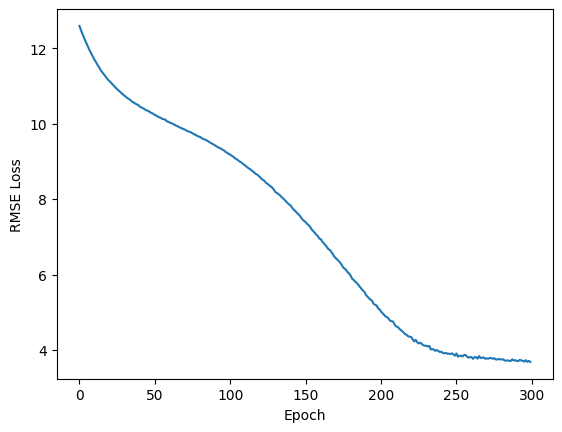

In [91]:
# Plot losses
plt.plot(range(epochs), losses)
plt.ylabel('RMSE Loss')
plt.xlabel('Epoch')
plt.savefig('training_loss.png')

In [97]:
loss

tensor(3.6835, device='cuda:0', grad_fn=<SqrtBackward0>)

In [99]:
for i in range(10):
    print(f'{i}.) Predicted: {y[i]}')

0.) Predicted: tensor([6.5000])
1.) Predicted: tensor([6.9000])
2.) Predicted: tensor([10.1000])
3.) Predicted: tensor([8.9000])
4.) Predicted: tensor([19.7000])
5.) Predicted: tensor([8.1000])
6.) Predicted: tensor([4.9000])
7.) Predicted: tensor([4.9000])
8.) Predicted: tensor([2.9000])
9.) Predicted: tensor([6.1000])


In [100]:
for i in range(10):
    print(f'{i}.) Predicted: {y[i].item():8.2f} True: {y_test[i].item():8.2f}')

0.) Predicted:     6.50 True:     2.90
1.) Predicted:     6.90 True:     5.70
2.) Predicted:    10.10 True:     7.70
3.) Predicted:     8.90 True:    12.50
4.) Predicted:    19.70 True:     4.10
5.) Predicted:     8.10 True:     5.30
6.) Predicted:     4.90 True:     3.70
7.) Predicted:     4.90 True:    14.50
8.) Predicted:     2.90 True:     5.70
9.) Predicted:     6.10 True:    10.10


In [101]:
for i in range(10):
    diff = np.abs(y[i].item()-y_test[i].item())
    print(f'{i}.) Predicted: {y[i].item():8.2f} True: {y_test[i].item():8.2f} Diff: {diff:8.2f}')

0.) Predicted:     6.50 True:     2.90 Diff:     3.60
1.) Predicted:     6.90 True:     5.70 Diff:     1.20
2.) Predicted:    10.10 True:     7.70 Diff:     2.40
3.) Predicted:     8.90 True:    12.50 Diff:     3.60
4.) Predicted:    19.70 True:     4.10 Diff:    15.60
5.) Predicted:     8.10 True:     5.30 Diff:     2.80
6.) Predicted:     4.90 True:     3.70 Diff:     1.20
7.) Predicted:     4.90 True:    14.50 Diff:     9.60
8.) Predicted:     2.90 True:     5.70 Diff:     2.80
9.) Predicted:     6.10 True:    10.10 Diff:     4.00


In [104]:
# Print predictions
print("\nSample Predictions:")
for i in range(10):
    diff = np.abs(y[i].item() - y_test[i].item())
    print(f'{i}.) Predicted: {y[i].item():8.2f} True: {y_test[i].item():8.2f} Diff: {diff:8.2f}')


Sample Predictions:
0.) Predicted:     6.50 True:     2.90 Diff:     3.60
1.) Predicted:     6.90 True:     5.70 Diff:     1.20
2.) Predicted:    10.10 True:     7.70 Diff:     2.40
3.) Predicted:     8.90 True:    12.50 Diff:     3.60
4.) Predicted:    19.70 True:     4.10 Diff:    15.60
5.) Predicted:     8.10 True:     5.30 Diff:     2.80
6.) Predicted:     4.90 True:     3.70 Diff:     1.20
7.) Predicted:     4.90 True:    14.50 Diff:     9.60
8.) Predicted:     2.90 True:     5.70 Diff:     2.80
9.) Predicted:     6.10 True:    10.10 Diff:     4.00


In [107]:
torch.save(model.state_dict(), 'Vasan_TaxiFare.pt')